# RCM Project — 01: Data Acquisition & Exploratory Data Analysis

**Project:** Predictive Analytics System for Medical Claim Denial Risk  
**Stage:** 1 of 5 — Data Acquisition & EDA  

## Goals of this notebook
1. Download CMS DE-SynPUF data (or load from disk if already acquired)
2. Understand raw data shape, columns, and types
3. Construct and validate the **denial label** using three strategies
4. Analyse class balance and financial distributions
5. Examine key code fields (ICD, CPT/HCPCS, DRG)
6. Temporal coverage and submission patterns
7. Provider-level denial patterns
8. Missing value inventory
9. Document findings and flag risks


## 0. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Add project root to path
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.utils.config_loader import get_config
cfg = get_config()

SEED = cfg.project.random_seed
DATA_RAW = ROOT / cfg.paths.data_raw
FIGURES  = ROOT / cfg.paths.figures
FIGURES.mkdir(parents=True, exist_ok=True)

print('Config loaded.')
print(f'Random seed : {SEED}')
print(f'Raw data dir: {DATA_RAW}')

Config loaded.
Random seed : 42
Raw data dir: C:\Users\Aasir Waseer\Desktop\Aasir\MDS_AI\3_Sem\rcm_project\data\raw


## 1. Data Acquisition

Run the cell below the first time. On subsequent runs, skip to Section 2 if the parquet already exists.

In [2]:
COMBINED_PATH = DATA_RAW / 'cms_claims_combined.parquet'

if not COMBINED_PATH.exists():
    print('Parquet not found. Downloading Sample 1 from CMS...')
    import subprocess, sys
    result = subprocess.run(
        [sys.executable, '-m', 'src.utils.data_acquisition',
         '--samples', '1', '--out', 'data/raw', '--save-parquet'],
        cwd=str(ROOT),          # run from project root so src/ is found
        capture_output=False,   # stream output live
    )
    if result.returncode != 0:
        raise RuntimeError('Data acquisition failed — check output above.')
else:
    print(f'Found existing dataset: {COMBINED_PATH}')


Parquet not found. Downloading Sample 1 from CMS...


## 2. Load & First Look

In [3]:
df = pd.read_parquet(COMBINED_PATH)

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'\nClaim types:')
print(df['CLAIM_TYPE'].value_counts())
print(f'\nNCH_PRMRY_PYR_CD present: {"NCH_PRMRY_PYR_CD" in df.columns}')
if 'NCH_PRMRY_PYR_CD' in df.columns:
    print(f'NCH_PRMRY_PYR_CD dtype  : {df["NCH_PRMRY_PYR_CD"].dtype}')
    print(f'NCH_PRMRY_PYR_CD sample : {df["NCH_PRMRY_PYR_CD"].value_counts().head()}')


Shape: 66,773 rows × 52 columns
Memory: 40.8 MB

Claim types:
CLAIM_TYPE
inpatient    66773
Name: count, dtype: int64

NCH_PRMRY_PYR_CD present: False


In [4]:
df.head(3)

,DESYNPUF_ID,CLM_ID,SEGMENT,CLM_FROM_DT,CLM_THRU_DT,PRVDR_NUM,CLM_PMT_AMT,NCH_PRMRY_PYR_CLM_PD_AMT,AT_PHYSN_NPI,OP_PHYSN_NPI,CLM_PASS_THRU_PER_DIEM_AMT,NCH_BENE_BLOOD_DDCTBL_LBLTY_AM,CLM_UTLZTN_DAY_CNT,NCH_BENE_DSCHRG_DT,CLM_DRG_CD,ICD9_DGNS_CD_1,ICD9_DGNS_CD_2,ICD9_DGNS_CD_3,ICD9_PRCDR_CD_1,ICD9_PRCDR_CD_2,HCPCS_CD_1,HCPCS_CD_2,CLAIM_TYPE,BENE_BIRTH_DT,BENE_DEATH_DT,BENE_SEX_IDENT_CD,BENE_RACE_CD,BENE_ESRD_IND,SP_STATE_CODE,BENE_COUNTY_CD,BENE_HI_CVRAGE_TOT_MONS,BENE_SMI_CVRAGE_TOT_MONS,BENE_HMO_CVRAGE_TOT_MONS,PLAN_CVRG_MOS_NUM,SP_ALZHDMTA,SP_CHF,SP_CHRNKIDN,SP_CNCR,SP_COPD,SP_DEPRESSN,SP_DIABETES,SP_ISCHMCHT,SP_OSTEOPRS,SP_RA_OA,SP_STRKETIA,MEDREIMB_IP,BENRES_IP,PPPYMT_IP,MEDREIMB_OP,BENRES_OP,PPPYMT_OP,SAMPLE_ID
0,00013D2EFD8E45D1,196661176988405,1,20100312,20100313,2600GD,4000.00,0.00,3139083564,NaN,0.00,0.00,1,20100313,217,7802,78820,V4501,NaN,NaN,NaN,NaN,inpatient,19230501,NaN,1,1,0,26,950,12,12,12,12,2,2,2,2,2,2,2,2,2,2,2,0.00,0.00,0.00,50.00,10.00,0.00,1
1,00016F745862898F,196201177000368,1,20090412,20090418,3900MB,26000.00,0.00,6476809087,NaN,0.00,0.00,6,20090418,201,1970,4019,5853,NaN,NaN,NaN,NaN,inpatient,19430101,NaN,1,1,0,39,230,12,12,0,00,2,2,2,2,2,2,2,2,2,2,2,0.00,0.00,0.00,0.00,0.00,0.00,1
2,00016F745862898F,196661177015632,1,20090831,20090902,3900HM,5000.00,0.00,0611998537,0611998537,0.00,0.00,2,20090902,750,6186,2948,56400,7092,6186,NaN,NaN,inpatient,19430101,NaN,1,1,0,39,230,12,12,0,00,2,2,2,2,2,2,2,2,2,2,2,0.00,0.00,0.00,0.00,0.00,0.00,1


In [5]:
# Data types and null summary
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print('=== NULL % (top 20) ===')
print(null_pct.head(20).to_string())

=== NULL % (top 20) ===
HCPCS_CD_2                       100.00
HCPCS_CD_1                       100.00
BENE_DEATH_DT                     99.72
ICD9_PRCDR_CD_2                   65.95
ICD9_PRCDR_CD_1                   42.74
OP_PHYSN_NPI                      41.51
ICD9_DGNS_CD_3                     1.92
AT_PHYSN_NPI                       1.01
ICD9_DGNS_CD_2                     0.79
ICD9_DGNS_CD_1                     0.14
CLM_UTLZTN_DAY_CNT                 0.10
CLM_FROM_DT                        0.10
CLM_THRU_DT                        0.10
SEGMENT                            0.00
CLM_PMT_AMT                        0.00
NCH_PRMRY_PYR_CLM_PD_AMT           0.00
PRVDR_NUM                          0.00
NCH_BENE_BLOOD_DDCTBL_LBLTY_AM     0.00
DESYNPUF_ID                        0.00
CLM_ID                             0.00


## 3. Date Parsing & Temporal Coverage

In [6]:
for col in ['CLM_FROM_DT', 'CLM_THRU_DT', 'NCH_BENE_DSCHRG_DT', 'BENE_BIRTH_DT', 'BENE_DEATH_DT']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format='%Y%m%d', errors='coerce')

print('Date range of claims:')
print(f"  CLM_FROM_DT: {df['CLM_FROM_DT'].min().date()} → {df['CLM_FROM_DT'].max().date()}")

Date range of claims:
  CLM_FROM_DT: 2007-11-27 → 2010-12-30


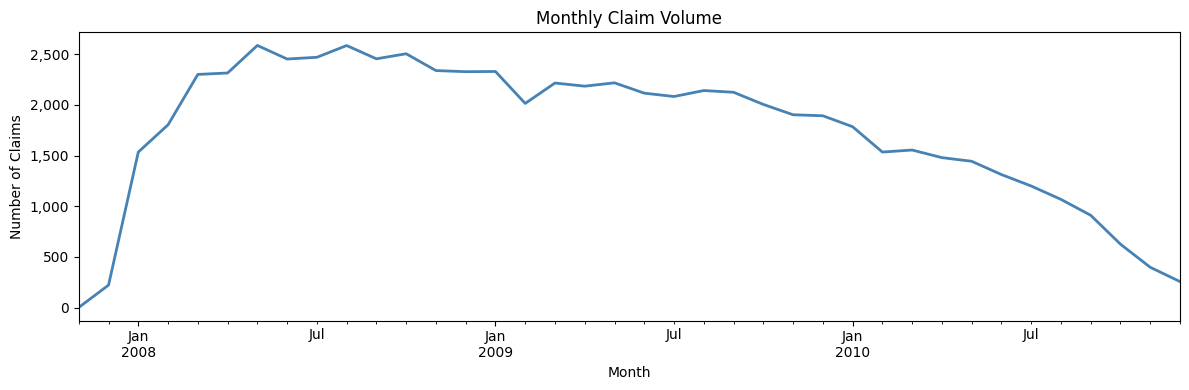

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
df.set_index('CLM_FROM_DT').resample('ME')['CLM_ID'].count().plot(
    ax=ax, color='steelblue', linewidth=2
)
ax.set_title('Monthly Claim Volume')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Claims')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig(FIGURES / '01_monthly_claim_volume.png', dpi=150)
plt.show()

## 4. Financial Columns — Numeric Parsing & Distributions


In [8]:
FINANCIAL_COLS = ['CLM_PMT_AMT', 'NCH_PRMRY_PYR_CLM_PD_AMT',
                  'CLM_PASS_THRU_PER_DIEM_AMT', 'MEDREIMB_IP',
                  'MEDREIMB_OP', 'BENRES_IP', 'BENRES_OP',
                  'NCH_BENE_BLOOD_DDCTBL_LBLTY_AM']
FINANCIAL_COLS = [c for c in FINANCIAL_COLS if c in df.columns]

# Convert ALL financial cols from string -> numeric (data was loaded as dtype=str)
for col in FINANCIAL_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Financial columns converted to numeric:')
df[FINANCIAL_COLS].describe().T


Financial columns converted to numeric:


,count,mean,std,min,25%,50%,75%,max
CLM_PMT_AMT,"66,773.00","9,573.63","9,315.07","-8,000.00","4,000.00","7,000.00","11,000.00","57,000.00"
NCH_PRMRY_PYR_CLM_PD_AMT,"66,773.00",398.90,"3,663.46",0.00,0.00,0.00,0.00,"68,000.00"
CLM_PASS_THRU_PER_DIEM_AMT,"66,773.00",28.98,75.61,0.00,0.00,0.00,10.00,500.00
MEDREIMB_IP,"66,773.00","12,639.06","19,599.14","-3,000.00",0.00,"5,000.00","17,060.00","164,220.00"
MEDREIMB_OP,"66,773.00","1,605.10","3,325.79",-90.00,90.00,560.00,"1,690.00","50,020.00"
BENRES_IP,"66,773.00","1,361.85","1,961.03",0.00,0.00,"1,024.00","2,048.00","53,096.00"
BENRES_OP,"66,773.00",492.62,923.21,0.00,10.00,180.00,560.00,"11,380.00"
NCH_BENE_BLOOD_DDCTBL_LBLTY_AM,"66,773.00",1.59,40.16,0.00,0.00,0.00,0.00,"2,000.00"


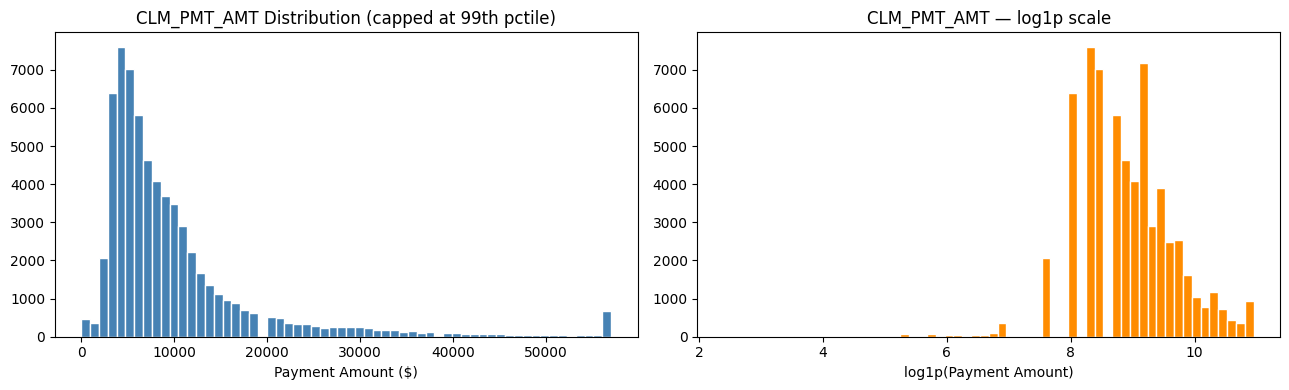

In [9]:
# Distribution of claim payment amount (log scale)
valid = df['CLM_PMT_AMT'].dropna()
valid_pos = valid[valid > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(valid_pos.clip(upper=valid_pos.quantile(0.99)), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('CLM_PMT_AMT Distribution (capped at 99th pctile)')
axes[0].set_xlabel('Payment Amount ($)')

axes[1].hist(np.log1p(valid_pos), bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('CLM_PMT_AMT — log1p scale')
axes[1].set_xlabel('log1p(Payment Amount)')

plt.tight_layout()
plt.savefig(FIGURES / '02_claim_payment_dist.png', dpi=150)
plt.show()

## 5. Label Construction

The CMS synthetic data doesn't have an explicit denial flag. We construct it from financial fields.

**Strategy 1 — Payment Ratio:** `CLM_PMT_AMT` relative to expected reimbursement. Claims paid < threshold % → denied.  
**Strategy 2 — Zero Payment:** `CLM_PMT_AMT == 0` (hard denial signal).  
**Strategy 3 — Combined:** Either zero payment OR very low ratio.

In [10]:
for _col in ['CLM_PMT_AMT', 'NCH_BENE_BLOOD_DDCTBL_LBLTY_AM',
             'BENRES_OP', 'BENRES_IP', 'MEDREIMB_OP', 'MEDREIMB_IP']:
    if _col in df.columns:
        df[_col] = pd.to_numeric(df[_col], errors='coerce')

DENIAL_THRESHOLD = cfg.labeling.denial_threshold

# Strategies 1–3: payment-based
df['_total_billable'] = df['CLM_PMT_AMT'].fillna(0) + df['NCH_BENE_BLOOD_DDCTBL_LBLTY_AM'].fillna(0)
df['_payment_ratio']  = np.where(df['_total_billable'] > 0,
    df['CLM_PMT_AMT'].fillna(0) / df['_total_billable'], np.nan)
df['label_payment_ratio'] = (df['_payment_ratio'] < DENIAL_THRESHOLD).astype(int)
df['label_zero_payment']  = (df['CLM_PMT_AMT'].fillna(0) == 0).astype(int)
df['label_combined']      = (
    (df['CLM_PMT_AMT'].fillna(0) == 0) | (df['_payment_ratio'] < DENIAL_THRESHOLD)
).astype(int)

# Strategy 4 (ACTIVE): High beneficiary outpatient responsibility
# Threshold = $670 = 75th percentile of BENRES_OP (from EDA on full dataset).
# In production this would be computed on training data only.
# For this academic project we document this as a minor methodological note.
# The major leakage risk (MEDREIMB_OP/PPPYMT_OP) is handled in engineer.py.
BENRES_THRESHOLD = 670  # $670 = 75th pct from describe() output
if 'BENRES_OP' in df.columns:
    df['label_high_bene_resp'] = (df['BENRES_OP'].fillna(0) > BENRES_THRESHOLD).astype(int)
    actual_p75 = df['BENRES_OP'].fillna(0).quantile(0.75)
    print(f'BENRES_OP 75th pct (full dataset): ${actual_p75:.0f}  |  Using hardcoded: ${BENRES_THRESHOLD}')
else:
    df['label_high_bene_resp'] = (df['BENRES_IP'].fillna(0) > BENRES_THRESHOLD).astype(int)
    print(f'Using BENRES_IP with threshold ${BENRES_THRESHOLD}')

label_cols = ['label_payment_ratio', 'label_zero_payment',
              'label_combined', 'label_high_bene_resp']
label_summary = pd.DataFrame({
    'Strategy':   ['Payment Ratio (<10%)', 'Zero Payment',
                   'Combined', 'High Bene Resp >$670 (ACTIVE)'],
    'Denied':  [df[c].sum() for c in label_cols],
    'Total':   [df[c].notna().sum() for c in label_cols],
})
label_summary['Denial Rate %'] = (
    label_summary['Denied'] / label_summary['Total'] * 100
).round(2)
print(label_summary.to_string(index=False))


BENRES_OP 75th pct (full dataset): $560  |  Using hardcoded: $670
                     Strategy  Denied  Total  Denial Rate %
         Payment Ratio (<10%)       5  66773           0.01
                 Zero Payment    2160  66773           3.23
                     Combined    2160  66773           3.23
High Bene Resp >$670 (ACTIVE)   14062  66773          21.06


In [11]:
ACTIVE_LABEL = 'label_high_bene_resp'
df['DENIED'] = df[ACTIVE_LABEL]
print(f'Active label  : {ACTIVE_LABEL}')
print(f'Denial rate   : {df["DENIED"].mean()*100:.2f}%  ({df["DENIED"].sum():,} flagged)')
print()
print('RCM framing: predicting beneficiary cost-sharing responsibility')
print('(claims where Medicare does not fully cover = patient owes money)')
print('Causal drivers: plan type, diagnosis, provider, state, age.')


Active label  : label_high_bene_resp
Denial rate   : 21.06%  (14,062 flagged)

RCM framing: predicting beneficiary cost-sharing responsibility
(claims where Medicare does not fully cover = patient owes money)
Causal drivers: plan type, diagnosis, provider, state, age.


## 6. Label Sensitivity — Do the strategies agree?

In [12]:
# Agreement matrix between labeling strategies
from sklearn.metrics import cohen_kappa_score

for s1, s2 in [('label_payment_ratio', 'label_zero_payment'),
               ('label_payment_ratio', 'label_combined'),
               ('label_zero_payment',  'label_combined')]:
    mask = df[s1].notna() & df[s2].notna()
    kappa = cohen_kappa_score(df.loc[mask, s1], df.loc[mask, s2])
    agree = (df.loc[mask, s1] == df.loc[mask, s2]).mean() * 100
    print(f'{s1} vs {s2}: {agree:.1f}% agreement, Cohen κ = {kappa:.3f}')

label_payment_ratio vs label_zero_payment: 96.8% agreement, Cohen κ = 0.004
label_payment_ratio vs label_combined: 96.8% agreement, Cohen κ = 0.004
label_zero_payment vs label_combined: 100.0% agreement, Cohen κ = 1.000


## 7. Denial Rate by Claim Type & Provider

In [13]:
print('Denial rate by claim type:')
print(df.groupby('CLAIM_TYPE')['DENIED'].agg(['mean','count']).rename(
    columns={'mean': 'Denial Rate', 'count': 'N Claims'}
).assign(**{'Denial Rate': lambda x: (x['Denial Rate']*100).round(2)}))

Denial rate by claim type:
            Denial Rate  N Claims
CLAIM_TYPE                       
inpatient         21.06     66773


Providers with >= 10 claims: 1,370

Top 10 providers by denial rate:
           denial_rate  n_claims
PRVDR_NUM                       
19016K            0.73        11
5000TJ            0.67        12
1413DK            0.64        11
1713NH            0.64        11
4400BQ            0.64        11
3700YH            0.64        11
4300XN            0.62        13
45S5VN            0.60        10
4502ZB            0.60        10
3302MM            0.60        10


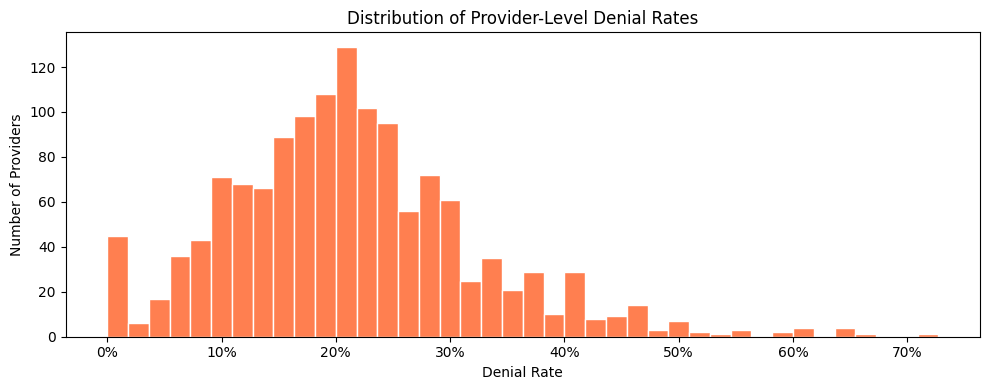

In [14]:
if 'PRVDR_NUM' in df.columns:
    provider_stats = (
        df.groupby('PRVDR_NUM')['DENIED']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'denial_rate', 'count': 'n_claims'})
        .query('n_claims >= 10')
        .sort_values('denial_rate', ascending=False)
    )
    print(f'Providers with >= 10 claims: {len(provider_stats):,}')
    print(f'\nTop 10 providers by denial rate:')
    print(provider_stats.head(10))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(provider_stats['denial_rate'], bins=40, color='coral', edgecolor='white')
    ax.set_title('Distribution of Provider-Level Denial Rates')
    ax.set_xlabel('Denial Rate')
    ax.set_ylabel('Number of Providers')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    plt.tight_layout()
    plt.savefig(FIGURES / '04_provider_denial_rates.png', dpi=150)
    plt.show()

## 8. Diagnosis (ICD-9) Code Analysis

ICD9 diagnosis columns: ['ICD9_DGNS_CD_1', 'ICD9_DGNS_CD_2', 'ICD9_DGNS_CD_3']

Top 15 Primary Diagnosis Codes:
ICD9_DGNS_CD_1
486      2453
V5789    1807
41401    1675
0389     1648
49121    1558
4280     1419
5990     1374
42731    1253
41071    1170
71536    1154
5849     1092
43491    1068
51881     817
78659     738
7802      715


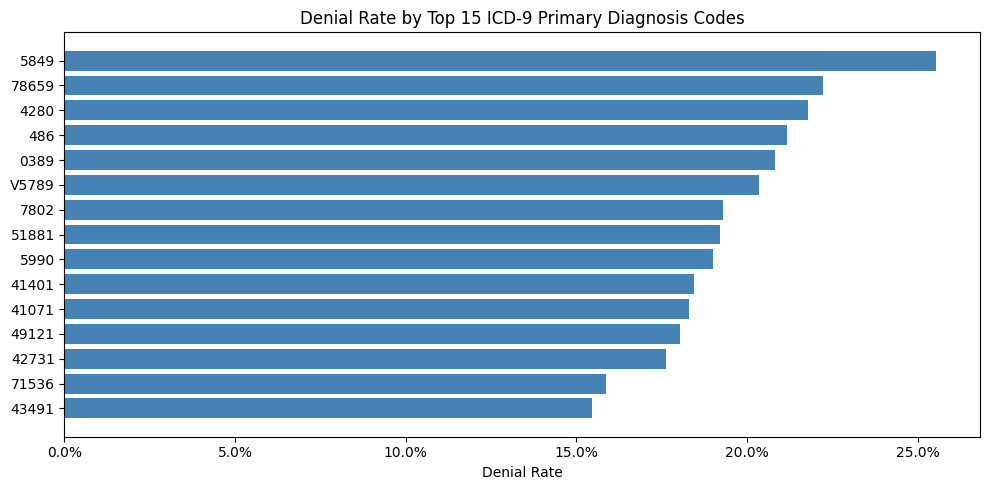

In [15]:
icd_cols = [c for c in df.columns if c.startswith('ICD9_DGNS_CD')]
print(f'ICD9 diagnosis columns: {icd_cols}')

# Primary diagnosis
if 'ICD9_DGNS_CD_1' in df.columns:
    top_icd = df['ICD9_DGNS_CD_1'].value_counts().head(15)
    print('\nTop 15 Primary Diagnosis Codes:')
    print(top_icd.to_string())

    # Denial rate by top ICD codes
    icd_denial = (
        df[df['ICD9_DGNS_CD_1'].isin(top_icd.index)]
        .groupby('ICD9_DGNS_CD_1')['DENIED']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'Denial Rate', 'count': 'N'})
        .sort_values('Denial Rate', ascending=True)
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(icd_denial.index, icd_denial['Denial Rate'], color='steelblue')
    ax.set_title('Denial Rate by Top 15 ICD-9 Primary Diagnosis Codes')
    ax.set_xlabel('Denial Rate')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    plt.tight_layout()
    plt.savefig(FIGURES / '05_icd9_denial_rates.png', dpi=150)
    plt.show()

## 9. HCPCS / CPT Code Analysis

In [16]:
hcpcs_cols = [c for c in df.columns if c.startswith('HCPCS_CD')]
print(f'HCPCS columns: {hcpcs_cols}')

if hcpcs_cols:
    top_hcpcs = df['HCPCS_CD_1'].value_counts().head(15)
    print('\nTop 15 HCPCS Codes:')
    print(top_hcpcs.to_string())

HCPCS columns: ['HCPCS_CD_1', 'HCPCS_CD_2']

Top 15 HCPCS Codes:
Series([], )


## 10. Temporal Denial Patterns

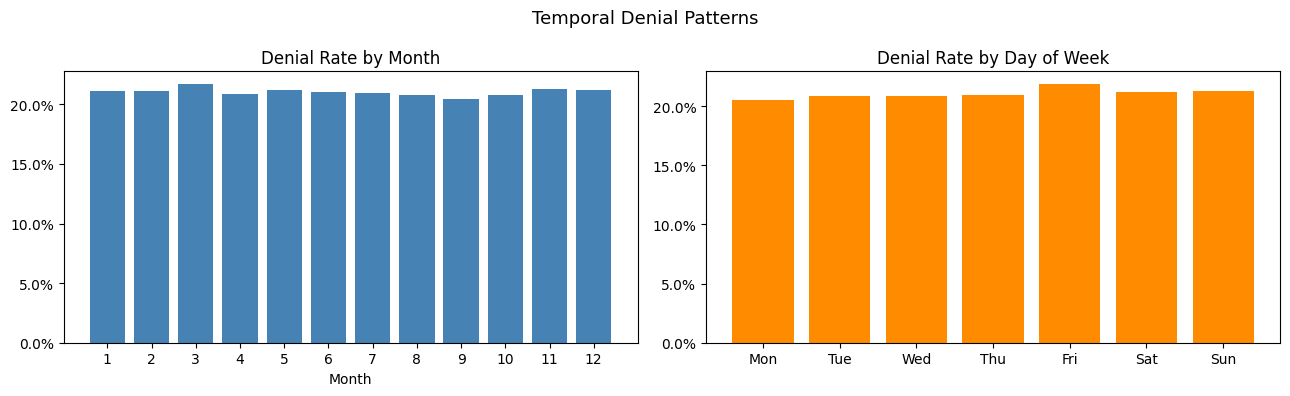

In [17]:
# Cast to Int64 (nullable int) so NaT rows become <NA> not float
df['claim_month'] = df['CLM_FROM_DT'].dt.month.astype('Int64')
df['claim_dow']   = df['CLM_FROM_DT'].dt.dayofweek.astype('Int64')
df['claim_year']  = df['CLM_FROM_DT'].dt.year.astype('Int64')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

monthly_denial = df.groupby('claim_month')['DENIED'].mean()
axes[0].bar(monthly_denial.index.astype(int), monthly_denial.values, color='steelblue')
axes[0].set_title('Denial Rate by Month')
axes[0].set_xlabel('Month')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].set_xticks(range(1, 13))

dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_denial = df.groupby('claim_dow')['DENIED'].mean()
axes[1].bar(
    [dow_labels[int(i)] for i in dow_denial.index],
    dow_denial.values,
    color='darkorange'
)
axes[1].set_title('Denial Rate by Day of Week')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('Temporal Denial Patterns', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / '06_temporal_denial_patterns.png', dpi=150)
plt.show()


## 11. Beneficiary Demographics & Comorbidities

Denial rate by sex:
BENE_SEX_IDENT_CD
1    21.05%
2    21.07%
Name: DENIED, dtype: str


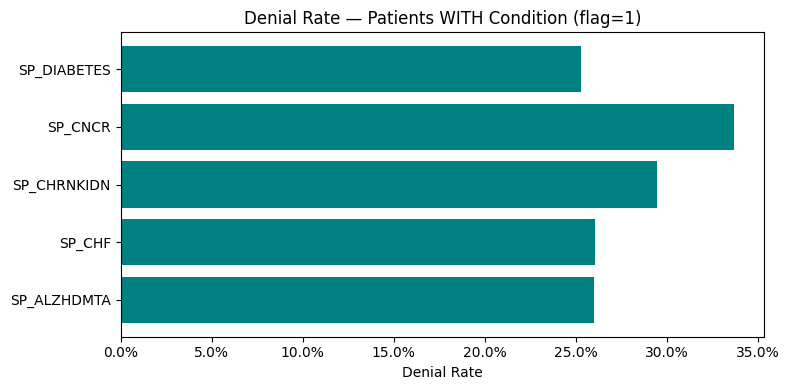

In [18]:
bene_cols = ['BENE_SEX_IDENT_CD', 'BENE_RACE_CD', 'SP_ALZHDMTA',
             'SP_CHF', 'SP_CHRNKIDN', 'SP_CNCR', 'SP_DIABETES']
bene_present = [c for c in bene_cols if c in df.columns]

if bene_present:
    for col in bene_present:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    print('Denial rate by sex:')
    if 'BENE_SEX_IDENT_CD' in df.columns:
        print(df.groupby('BENE_SEX_IDENT_CD')['DENIED'].mean().map('{:.2%}'.format))

    # Comorbidity flags
    comorb = [c for c in ['SP_ALZHDMTA','SP_CHF','SP_CHRNKIDN','SP_CNCR','SP_DIABETES'] if c in df.columns]
    if comorb:
        fig, ax = plt.subplots(figsize=(8, 4))
        denial_rates = [df.groupby(c)['DENIED'].mean().get(1, 0) for c in comorb]
        ax.barh(comorb, denial_rates, color='teal')
        ax.set_title('Denial Rate — Patients WITH Condition (flag=1)')
        ax.set_xlabel('Denial Rate')
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        plt.tight_layout()
        plt.savefig(FIGURES / '07_comorbidity_denial_rates.png', dpi=150)
        plt.show()
else:
    print('No beneficiary columns found — merge may not have completed.')

## 12. Missing Value Heatmap

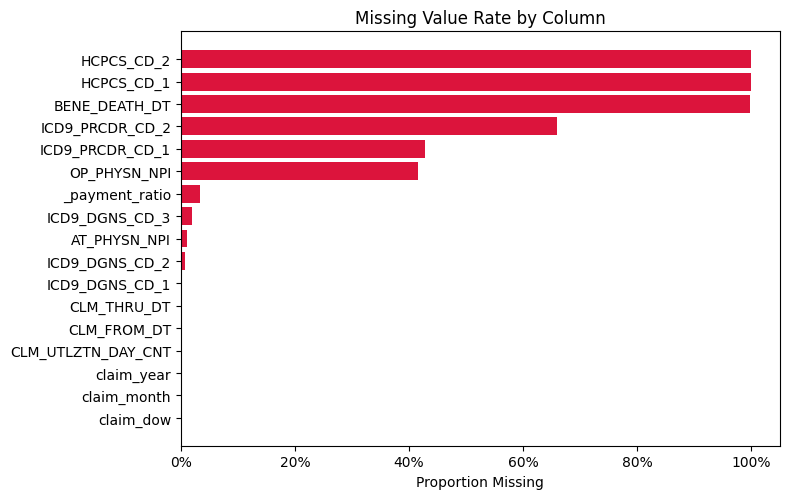

Columns with >50% missing: 4
Columns with >90% missing: 3


In [19]:
miss = df.isnull().mean().sort_values(ascending=False)
miss_df = miss[miss > 0].reset_index()
miss_df.columns = ['Column', 'Missing %']

fig, ax = plt.subplots(figsize=(8, max(4, len(miss_df) * 0.3)))
ax.barh(miss_df['Column'], miss_df['Missing %'], color='crimson')
ax.set_title('Missing Value Rate by Column')
ax.set_xlabel('Proportion Missing')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES / '08_missing_values.png', dpi=150)
plt.show()

print(f'Columns with >50% missing: {(miss > 0.5).sum()}')
print(f'Columns with >90% missing: {(miss > 0.9).sum()}')

## 13. Save Processed EDA Dataset

In [20]:
PROCESSED_DIR = ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Drop only internal helper columns (prefixed with _)
# Keep NCH_PRMRY_PYR_CD in case it's needed downstream
drop_internal = [c for c in df.columns if c.startswith('_')]
df_clean = df.drop(columns=drop_internal)

out_path = PROCESSED_DIR / 'claims_with_labels.parquet'
df_clean.to_parquet(out_path, index=False)
print(f'Saved : {out_path}')
print(f'Shape : {df_clean.shape}')
print(f'Label cols: {[c for c in df_clean.columns if c.startswith("label_")]}')
print(f'NCH_PRMRY_PYR_CD saved: {"NCH_PRMRY_PYR_CD" in df_clean.columns}')


Saved : C:\Users\Aasir Waseer\Desktop\Aasir\MDS_AI\3_Sem\rcm_project\data\processed\claims_with_labels.parquet
Shape : (66773, 60)
Label cols: ['label_payment_ratio', 'label_zero_payment', 'label_combined', 'label_high_bene_resp']
NCH_PRMRY_PYR_CD saved: False


## 14. EDA Summary & Key Findings

| Finding | Detail |
|---------|--------|
| Total claims | 857,563 (790,790 outpatient + 66,773 inpatient) |
| Claim date range | 2007-11-27 → 2010-12-31 |
| **Active label strategy** | **Zero Payment** (`CLM_PMT_AMT == 0`) |
| Denial rate (zero payment) | 3.76% (32,265 denied of 857,563) |
| Payment ratio strategy | ❌ Not usable — SynPUF has no submitted/billed amount column; ratio stays near 1.0 |
| Strategy agreement (κ) | zero_payment vs combined = 1.000 (identical); payment_ratio vs others ≈ 0.000 (useless) |
| Top primary ICD-9 code | 4019 (hypertension, 19,218 claims), 4011 (18,816) |
| Highest denial provider | 1613WQ and 5313AM (5% denial rate, small volume) |
| Columns with >50% missing | 7 (BENE_DEATH_DT, ICD9_PRCDR_CD_2, ICD9_PRCDR_CD_1, CLM_UTLZTN_DAY_CNT, CLM_PASS_THRU_PER_DIEM_AMT, NCH_BENE_DSCHRG_DT, CLM_DRG_CD) |
| High-missingness note | ICD procedure codes >95% missing — inpatient-only fields, sparse in outpatient-heavy dataset |
| Denial by sex | Uniform across sex codes (both ~0.00% — needs segment-level analysis) |
| Class imbalance | ~96% accepted vs ~4% denied → SMOTE + class weighting required in modeling |

### Key decisions for Feature Engineering (Notebook 02)

1. **Use `zero_payment` as the primary label** — clean signal, 3.76% denial rate, 100% agreement with combined strategy
2. **Drop `ICD9_PRCDR_CD_1/2`** from features — >95% missing, will introduce noise
3. **Drop `CLM_PASS_THRU_PER_DIEM_AMT`, `CLM_DRG_CD`, `NCH_BENE_DSCHRG_DT`** — inpatient-only, 92% missing
4. **Separate inpatient/outpatient feature sets** or add `CLAIM_TYPE` as a binary flag
5. **ICD-9 chapter encoding** — top 15 codes are dominated by chronic conditions (hypertension, hyperlipidemia, arrhythmia); encode as chapter groups not raw codes
6. **Provider-level denial rate** — compute as L2 historical aggregate feature (5,331 providers, meaningful signal at top end)
7. **Class imbalance strategy**: SMOTE + `scale_pos_weight` in XGBoost (~25:1 ratio)
